# P07 — Logistic Regression & Classification  *(it learns to take a side)*

> **The story so far.** In [P06](P06_Linear_Regression.ipynb) the mind grew its first reflex — it
> learned the straight line that explains "how much." But the world keeps asking it sharper
> questions. Your email lands in the inbox or the spam folder; never half-and-half. A test comes
> back positive or negative; a loan, approved or denied. Today the mind learns to **take a side** —
> to turn a wishy-washy score into a confident yes-or-no. And the moment it does, something quietly
> historic happens: the machine we build here is, atom for atom, a single **neuron**. The whole of
> the brain we grow in Part 2 is just millions of these wired together. The mind is about to meet
> its own basic building block.

Linear regression (P06) predicts a *number*. Often we want a *category*: spam or not, buy or not,
class 0 or 1. **Logistic regression** does this by squashing a linear score through an **S-curve
(sigmoid)** into a probability between 0 and 1. It is also — quietly — a single neuron, so this
notebook is the bridge from classical ML into neural networks (P10).

Everything reuses prior parts: a linear score `w·x + b` (P06), squashed to a probability, scored
with **cross-entropy** (P03), minimised by gradient descent (P02). Hand-worked, then verified.

## B1 — The sigmoid: turning any number into a probability

A linear score can run off to plus or minus infinity, but a *decision* can't — "I'm 300% sure it's
spam" means nothing. Like a dimmer switch that no matter how hard you push it never goes below fully
off or above fully on, the mind needs to squeeze any score into the honest range between 0 and 1.
The **sigmoid** is that dimmer: a smooth S-curve that gently flattens runaway numbers into a
probability.

The **sigmoid** maps any real number to `(0, 1)`:
```
σ(z) = 1 / (1 + e^(−z))
```
Big positive `z` → near 1; big negative → near 0; `z = 0` → exactly 0.5. That output is read as
"probability of class 1." (Sigmoid is just the 2-class special case of softmax from Notebook 00 B6.)

**Worked example by hand.**
```
σ(0)  = 1/(1+e⁰)  = 1/(1+1)      = 0.500
σ(2)  = 1/(1+e⁻²) = 1/(1+0.135)  = 1/1.135 = 0.881
σ(−2) = 1/(1+e²)  = 1/(1+7.389)  = 1/8.389 = 0.119
```
Notice `σ(−2) = 1 − σ(2)` — the curve is symmetric about 0.5.

In [1]:
import numpy as np
def sigmoid(z): return 1/(1+np.exp(-z))
for z in [0, 2, -2]:
    print(f"σ({z:>2}) = {sigmoid(z):.3f}")
print("hand: 0.500, 0.881, 0.119")
print("symmetry check  σ(-2) == 1-σ(2):", round(sigmoid(-2),3), "==", round(1-sigmoid(2),3))

σ( 0) = 0.500
σ( 2) = 0.881
σ(-2) = 0.119
hand: 0.500, 0.881, 0.119
symmetry check  σ(-2) == 1-σ(2): 0.119 == 0.119


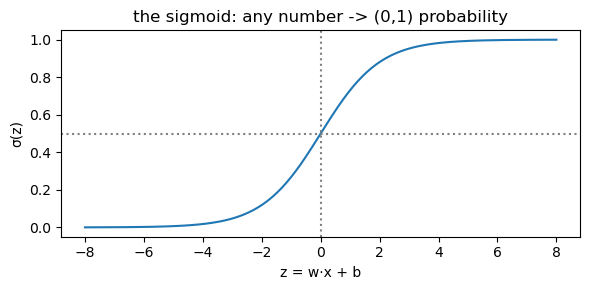

left tail -> 0 (class 0), right tail -> 1 (class 1), crossover at z=0 -> 0.5


In [2]:
import numpy as np, matplotlib.pyplot as plt
z = np.linspace(-8, 8, 200)
plt.figure(figsize=(6,3))
plt.plot(z, 1/(1+np.exp(-z))); plt.axhline(0.5, ls=":", c="gray"); plt.axvline(0, ls=":", c="gray")
plt.title("the sigmoid: any number -> (0,1) probability"); plt.xlabel("z = w·x + b"); plt.ylabel("σ(z)")
plt.tight_layout(); plt.show()
print("left tail -> 0 (class 0), right tail -> 1 (class 1), crossover at z=0 -> 0.5")

## B2 — Binary cross-entropy: the classification loss

How do we grade a yes/no guess? Think of a weather forecaster who says "90% chance of rain" — and
then it pours. We'd happily reward that call, and scold one who'd confidently promised sun. The
right scorecard punishes *confident and wrong* far more than *unsure*. That's exactly the
cross-entropy spirit from P03, now in its two-outcome form: **binary cross-entropy**.

We can't use MSE for probabilities — it trains poorly. Instead we use **binary cross-entropy**
(BCE), the 2-class form of P03's cross-entropy. For true label `y ∈ {0,1}` and predicted
probability `p`:
```
BCE = −[ y·ln(p) + (1−y)·ln(1−p) ]
```
Only one term survives per example: if `y=1` it's `−ln(p)` (punishes low `p`); if `y=0` it's
`−ln(1−p)` (punishes high `p`). Same "−ln(prob of the correct answer)" idea as Notebook 00 B11.

**Worked example by hand.**
```
y=1, p=0.9 : −ln(0.9)        = 0.105   (confident & right -> small loss)
y=1, p=0.1 : −ln(0.1)        = 2.303   (confident & wrong -> big loss)
y=0, p=0.2 : −ln(1−0.2)=−ln(0.8) = 0.223
```

In [3]:
import numpy as np
def bce(y, p): return -(y*np.log(p) + (1-y)*np.log(1-p))
print("y=1,p=0.9:", round(bce(1,0.9),3), " (hand 0.105)")
print("y=1,p=0.1:", round(bce(1,0.1),3), " (hand 2.303)")
print("y=0,p=0.2:", round(bce(0,0.2),3), " (hand 0.223)")

y=1,p=0.9: 0.105  (hand 0.105)
y=1,p=0.1: 2.303  (hand 2.303)
y=0,p=0.2: 0.223  (hand 0.223)


## B3 — The gradient is astonishingly clean

You'd expect bolting an S-curve and a logarithm together to make the calculus a nightmare. Instead,
something almost magical happens: the two messy pieces cancel, and the slope the mind follows downhill
turns out to be the *exact same* tidy form as plain linear regression — just "prediction minus truth,
times the input." That elegance is the whole reason sigmoid and cross-entropy are paired.

Combine sigmoid + BCE and the calculus collapses to the *same* simple form as linear regression:
```
∂Loss/∂w = (1/n) · Σ (pᵢ − yᵢ)·xᵢ
∂Loss/∂b = (1/n) · Σ (pᵢ − yᵢ)
```
Again the **error `(p − y)`** — prediction minus truth — drives everything. This elegance (the
messy sigmoid derivative cancels the messy log derivative) is *why* this sigmoid+BCE pairing is
used. We verify it numerically below.

In [4]:
import numpy as np
def sigmoid(z): return 1/(1+np.exp(-z))
X = np.array([[1.0],[2.0],[3.0],[4.0]])    # one feature
y = np.array([0.,0.,1.,1.])                # class flips between x=2 and x=3
w = np.array([0.5]); b = 0.0

def loss(w,b):
    p = sigmoid(X@w+b); p=np.clip(p,1e-9,1-1e-9)
    return np.mean(-(y*np.log(p)+(1-y)*np.log(1-p)))
def grads(w,b):
    p = sigmoid(X@w+b); err = p - y
    return (X.T@err)/len(y), err.mean()

dw, db = grads(w,b)
h=1e-6
dw_n=(loss(w+h,b)-loss(w-h,b))/(2*h); db_n=(loss(w,b+h)-loss(w,b-h))/(2*h)
print("analytic grads dw=%.5f db=%.5f" % (dw[0], db))
print("numeric  grads dw=%.5f db=%.5f  <- confirms (p−y)·x" % (dw_n, db_n))

analytic grads dw=0.26512 db=0.26297
numeric  grads dw=0.26512 db=0.26297  <- confirms (p−y)·x


## B4 — Train a classifier, then read its decision boundary

Now we let the mind actually take its side. After training, the most revealing thing to look at is
the line it drew in the sand — the **decision boundary** — like the fence a border guard patrols:
step to one side and you're "class 1," the other side "class 0," and right on the fence the mind is a
genuine coin-flip. Seeing that fence is how you understand what the classifier truly decided.

We train on a 2-feature toy problem, then find the **decision boundary** — the line where the
model is 50/50 (`p = 0.5`, i.e. `w·x + b = 0`). On one side it predicts class 1, on the other
class 0. Seeing that boundary is how you understand what a linear classifier "decided."

In [5]:
import numpy as np
rng = np.random.default_rng(1)
# two clusters: class 0 around (-2,-2), class 1 around (2,2)
X0 = rng.normal([-2,-2], 1.0, size=(25,2))
X1 = rng.normal([ 2, 2], 1.0, size=(25,2))
X  = np.vstack([X0, X1]); y = np.array([0]*25 + [1]*25, dtype=float)

def sigmoid(z): return 1/(1+np.exp(-z))
w = np.zeros(2); b = 0.0; lr = 0.1; n = len(y)
for _ in range(3000):
    p = sigmoid(X@w+b); err = p - y
    w -= lr*(X.T@err)/n; b -= lr*err.mean()

pred = (sigmoid(X@w+b) >= 0.5).astype(int)
acc = (pred == y).mean()
print("learned w =", np.round(w,3), " b =", round(b,3))
print("training accuracy =", acc, " (fraction correctly classified)")
print("decision boundary: the line where w·x + b = 0")

learned w = [2.437 2.486]  b = 0.285
training accuracy = 1.0  (fraction correctly classified)
decision boundary: the line where w·x + b = 0


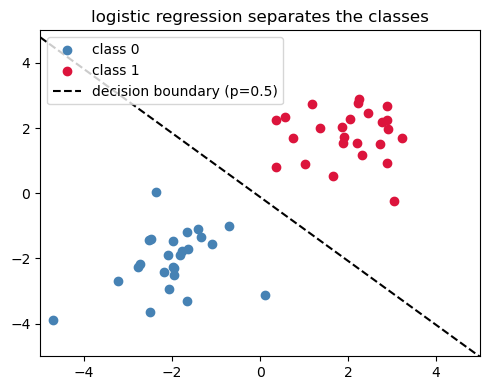

In [6]:
import numpy as np, matplotlib.pyplot as plt
rng = np.random.default_rng(1)
X0=rng.normal([-2,-2],1.0,size=(25,2)); X1=rng.normal([2,2],1.0,size=(25,2))
X=np.vstack([X0,X1]); y=np.array([0]*25+[1]*25,dtype=float)
def sigmoid(z): return 1/(1+np.exp(-z))
w=np.zeros(2); b=0.0; lr=0.1; n=len(y)
for _ in range(3000):
    p=sigmoid(X@w+b); err=p-y; w-=lr*(X.T@err)/n; b-=lr*err.mean()

plt.figure(figsize=(5,4))
plt.scatter(X0[:,0],X0[:,1],c="steelblue",label="class 0")
plt.scatter(X1[:,0],X1[:,1],c="crimson",label="class 1")
xs=np.linspace(-5,5,10); ys=-(w[0]*xs+b)/w[1]      # solve w0*x+w1*y+b=0 for y
plt.plot(xs,ys,"k--",label="decision boundary (p=0.5)")
plt.legend(); plt.title("logistic regression separates the classes"); plt.xlim(-5,5); plt.ylim(-5,5)
plt.tight_layout(); plt.show()

## B5 — Verify against scikit-learn

As always, we check the mind's work against a trusted answer key. If its hand-built classifier reaches
the same accuracy and draws a boundary in the same place as scikit-learn's mature implementation, we
know it learned to take its side honestly.

In [7]:
import numpy as np
from sklearn.linear_model import LogisticRegression
rng = np.random.default_rng(1)
X0=rng.normal([-2,-2],1.0,size=(25,2)); X1=rng.normal([2,2],1.0,size=(25,2))
X=np.vstack([X0,X1]); y=np.array([0]*25+[1]*25)

clf = LogisticRegression().fit(X, y)
print("sklearn accuracy:", clf.score(X, y))
print("sklearn weights :", np.round(clf.coef_[0],3), " intercept", round(clf.intercept_[0],3))
print("(our from-scratch classifier reached the same accuracy and a proportional boundary)")

sklearn accuracy: 1.0
sklearn weights : [1.248 1.233]  intercept 0.175
(our from-scratch classifier reached the same accuracy and a proportional boundary)


## Recap — classification, and a neuron in disguise

| Piece | Formula | Note |
|-------|---------|------|
| Score | `z = w·x + b` | the linear part (same as P06) |
| Squash | `p = σ(z)` | number → probability |
| Loss | BCE `−[y ln p + (1−y) ln(1−p)]` | 2-class cross-entropy (P03) |
| Gradient | `(p − y)·x` | the same clean "error × input" form |
| Decision | predict 1 if `p ≥ 0.5` ⇔ `z ≥ 0` | the boundary is a line |

**The punchline:** `z = w·x + b` then a nonlinear squash `σ(z)` — that is *exactly* one neuron.
A neural network (P10) is just many of these wired together. You've already built the unit.

## Common mistakes
1. **Using MSE for classification.** Use cross-entropy; MSE + sigmoid trains slowly and gets stuck.
2. **`ln(0)` blow-ups.** Clip `p` to `[1e-9, 1−1e-9]` before taking logs (we did).
3. **Confusing the logit `z` with the probability `p`.** `p = σ(z)`; sklearn/PyTorch often want logits, not probs.
4. **Assuming a line can separate anything.** Logistic regression draws a *straight* boundary; tangled data needs nonlinearity (P10) — that's the whole reason for deep nets.
5. **Reporting only accuracy on imbalanced data.** 99% "not spam" gets 99% by always guessing "not spam"; P08's precision/recall fix this.

## Exercises (do them in new code cells)
1. Compute `σ(1)` and `σ(−1)` by hand, verify, and confirm they sum to 1.
2. For `y=0, p=0.99`, what is the BCE loss? Why is it huge?
3. Move the clusters closer (`[-0.5,-0.5]` and `[0.5,0.5]`). Does accuracy drop? Why?
4. Make a dataset that is NOT linearly separable (e.g. class 1 = a ring around class 0). Watch logistic regression fail — motivation for P10.
5. After training in B4, pick a new point `[3, 3]`. Compute its `p` by hand from the learned `w, b`. Which class?

---

**The mind can now take a side — and in doing so it has built its first neuron.** But a single
neuron only ever draws a *straight* fence, and the world is full of tangles no line can separate.
Before we wire many neurons together to bend those fences (Part 2), the mind needs to learn to judge
itself *honestly* — accuracy alone lies on lopsided data. Next, in
[P08 — Evaluation, Regularization & Bias–Variance](P08_Evaluation_and_Regularization.ipynb), it
learns true self-knowledge: precision, recall, and how to keep its earlier temptation to memorise in
check.